# Phase 2: RG Monotone and Coupling Flow

Learn a scalar RG monotone function $C(\mathbf{J})$ over the coupling space
$\mathbf{J} = (\beta_\text{plaq},\; \beta_\text{rect\_x},\; \beta_\text{rect\_y})$,
such that the gradient flow $d\mathbf{J}/d\ell = -\nabla_{\mathbf{J}} C(\mathbf{J})$
predicts the optimal coarse action coupling for any fine-lattice coupling.

**Two-stage approach:**
1. **Data collection** — run Phase 1 `train_learned_rg` at a grid of $\beta$ values to collect $(\mathbf{J}_\text{fine}, \mathbf{J}_\text{coarse})$ pairs
2. **Monotone fitting** — train a small MLP $C_\theta\colon \mathbb{R}^3 \to \mathbb{R}$ so its gradient flow maps each $\mathbf{J}_\text{fine}$ to the corresponding $\mathbf{J}_\text{coarse}$

**Sections:**
1. Setup
2. Stage 1 — multi-$\beta$ data collection
3. Collected coupling landscape
4. Stage 2 — monotone training
5. Training curves
6. Predicted vs actual couplings
7. $\beta$ function (flow velocity)
8. RG monotone landscape
9. Summary

In [1]:
import pickle
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt

from inverserg.baselines import tree_level_coarse_beta
from inverserg.training import RGTrainingConfig
from inverserg.monotone import (
    CollectedRGData,
    MonotoneTrainingConfig,
    MonotoneTrainingResult,
    RGMonotone,
    collect_multi_beta_data,
    rg_flow_step,
    train_rg_monotone,
)

torch.manual_seed(42)

BETA_GRID = [2.0, 3.0, 4.0, 5.0, 6.0, 8.0]
FINE_L = 8
N_CONFIGS = 48
EPOCHS_PHASE1 = 30
EPOCHS_MONOTONE = 800

CACHE_DIR = Path("../artifacts/cache_phase2")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Beta grid: {BETA_GRID}")
print(f"Fine lattice: L={FINE_L}, configs per beta: {N_CONFIGS}")
print(f"Phase 1 epochs per beta: {EPOCHS_PHASE1}")
print(f"Monotone training epochs: {EPOCHS_MONOTONE}")
print(f"Cache dir: {CACHE_DIR}")

Beta grid: [2.0, 3.0, 4.0, 5.0, 6.0, 8.0]
Fine lattice: L=8, configs per beta: 48
Phase 1 epochs per beta: 30
Monotone training epochs: 800
Cache dir: ../artifacts/cache_phase2


## Stage 1: Multi-$\beta$ Data Collection

Run Phase 1 learned-RG training at each $\beta$ value in the grid.
For each $\beta$, we obtain the optimised coarse-action coefficients
$\mathbf{J}_\text{coarse}^*$.  Results are cached to disk.

In [2]:
config_template = RGTrainingConfig(
    fine_lattice_size=FINE_L,
    n_fine_samples=N_CONFIGS,
    n_model_samples=N_CONFIGS,
    epochs=EPOCHS_PHASE1,
    sampler_burn_in=32,
    sampler_thin=2,
    hmc_steps=6,
    hmc_step_size=0.15,
    blocker_type="fixed",
)

collected = collect_multi_beta_data(
    beta_values=BETA_GRID,
    config_template=config_template,
    cache_path=CACHE_DIR / "multi_beta_pairs.json",
    verbose=True,
)
print(f"\nCollected {len(collected.beta_values)} coupling pairs.")
print(f"J_fine shape:  {collected.J_fine.shape}")
print(f"J_coarse shape: {collected.J_coarse.shape}")

Loading cached data from ../artifacts/cache_phase2/multi_beta_pairs.json

Collected 6 coupling pairs.
J_fine shape:  torch.Size([6, 3])
J_coarse shape: torch.Size([6, 3])


## Collected Coupling Landscape

Compare the learned coarse couplings with the tree-level prediction $\beta_c = \beta_f / 4$.

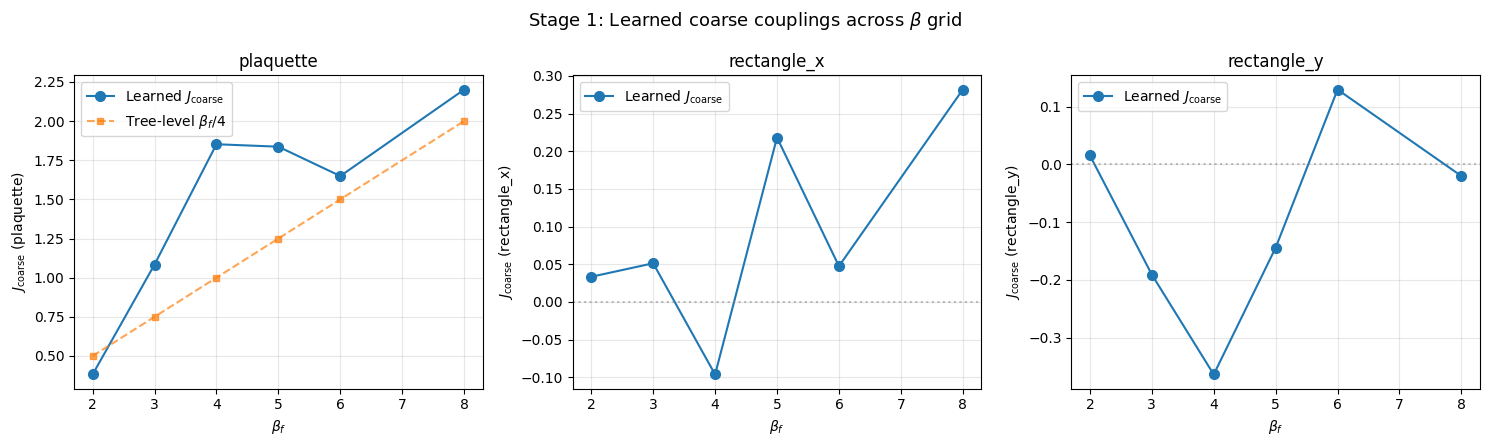

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
basis_names = list(collected.basis)
betas = np.array(collected.beta_values)
tree_plaq = np.array([tree_level_coarse_beta(b) for b in betas])

for idx, name in enumerate(basis_names):
    ax = axes[idx]
    actual = collected.J_coarse[:, idx].numpy()
    ax.plot(betas, actual, "o-", label="Learned $J_\\mathrm{coarse}$", markersize=7)
    if name == "plaquette":
        ax.plot(betas, tree_plaq, "s--", label="Tree-level $\\beta_f/4$", markersize=5, alpha=0.7)
    else:
        ax.axhline(0, ls=":", color="gray", alpha=0.5)
    ax.set_xlabel("$\\beta_f$")
    ax.set_ylabel(f"$J_\\mathrm{{coarse}}$ ({name})")
    ax.set_title(name)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Stage 1: Learned coarse couplings across $\\beta$ grid", fontsize=13)
fig.tight_layout()
plt.show()

In [4]:
print(f"{'beta':>6s}  {'plaq_learned':>12s}  {'plaq_tree':>10s}  {'rect_x':>10s}  {'rect_y':>10s}  {'mismatch':>10s}")
print("-" * 72)
for i, beta in enumerate(collected.beta_values):
    jc = collected.J_coarse[i]
    bt = tree_level_coarse_beta(beta)
    mm = collected.metrics[i].get("final_mismatch", float("nan"))
    print(f"{beta:6.1f}  {jc[0]:12.4f}  {bt:10.4f}  {jc[1]:10.4f}  {jc[2]:10.4f}  {mm:10.6f}")

  beta  plaq_learned   plaq_tree      rect_x      rect_y    mismatch
------------------------------------------------------------------------
   2.0        0.3819      0.5000      0.0334      0.0154    0.017076
   3.0        1.0837      0.7500      0.0513     -0.1907    0.040737
   4.0        1.8519      1.0000     -0.0961     -0.3636    0.072549
   5.0        1.8362      1.2500      0.2181     -0.1442    0.056370
   6.0        1.6488      1.5000      0.0475      0.1294    0.061074
   8.0        2.2009      2.0000      0.2817     -0.0203    0.020048


## Stage 2: Monotone Training

Train a small MLP $C_\theta\colon \mathbb{R}^3 \to \mathbb{R}$ such that
Euler integration of $d\mathbf{J}/d\ell = -\nabla C_\theta(\mathbf{J})$
maps each $\mathbf{J}_\text{fine}$ to its corresponding $\mathbf{J}_\text{coarse}^*$.

In [5]:
mono_config = MonotoneTrainingConfig(
    hidden_dim=64,
    n_layers=3,
    n_euler_steps=20,
    learning_rate=3e-3,
    epochs=EPOCHS_MONOTONE,
    weight_decay=1e-4,
)

mono_cache = CACHE_DIR / "monotone_result.json"
mono_state_cache = CACHE_DIR / "monotone_state.pt"

if mono_cache.exists() and mono_state_cache.exists():
    print("Loading monotone from cache ...")
    result = MonotoneTrainingResult.load(mono_cache)
    monotone = RGMonotone(coupling_dim=collected.J_fine.shape[1],
                          hidden_dim=mono_config.hidden_dim,
                          n_layers=mono_config.n_layers)
    monotone.load_state_dict(torch.load(mono_state_cache, weights_only=True))
    print("Loaded.")
else:
    print("Training RG monotone ...")
    monotone, result = train_rg_monotone(collected, config=mono_config, verbose=True)
    result.save(mono_cache)
    torch.save(monotone.state_dict(), mono_state_cache)
    print(f"\nSaved monotone to {mono_cache}")

Loading monotone from cache ...
Loaded.


## Training Curves

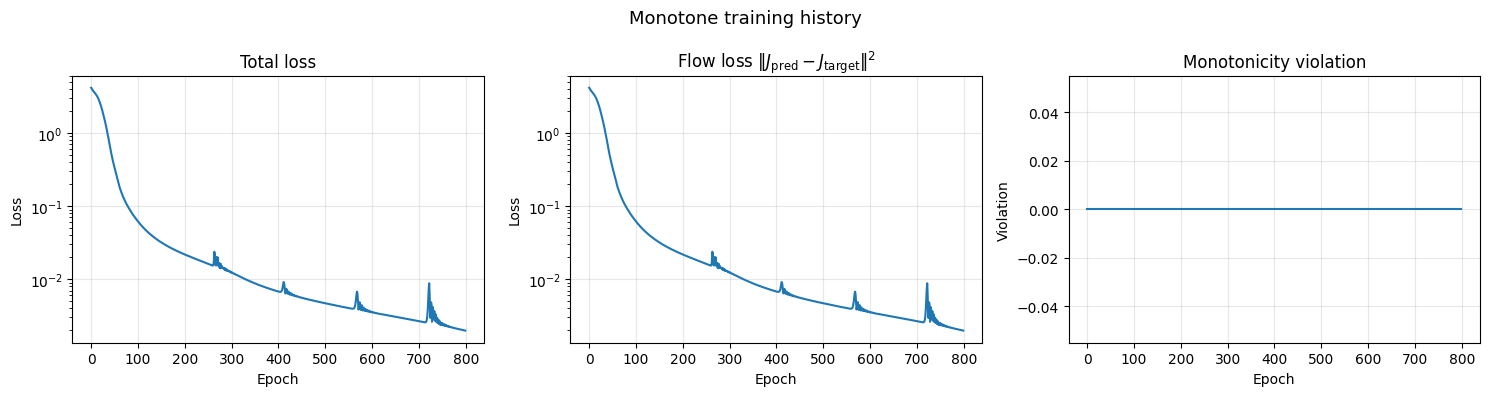

Final flow loss: 0.001986
Final total loss: 0.001986


In [6]:
epochs = [h["epoch"] for h in result.history]
losses = [h["loss"] for h in result.history]
flow_losses = [h["flow_loss"] for h in result.history]
mono_viols = [h["monotone_violation"] for h in result.history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].semilogy(epochs, losses)
axes[0].set_title("Total loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(epochs, flow_losses)
axes[1].set_title("Flow loss $\\|J_\\mathrm{pred} - J_\\mathrm{target}\\|^2$")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, mono_viols)
axes[2].set_title("Monotonicity violation")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Violation"); axes[2].grid(True, alpha=0.3)

fig.suptitle("Monotone training history", fontsize=13)
fig.tight_layout()
plt.show()

print(f"Final flow loss: {flow_losses[-1]:.6f}")
print(f"Final total loss: {losses[-1]:.6f}")

## Predicted vs Actual Couplings

Compare the monotone-predicted $\mathbf{J}_\text{coarse}$ (from gradient flow)
against the independently trained values and the tree-level baseline.

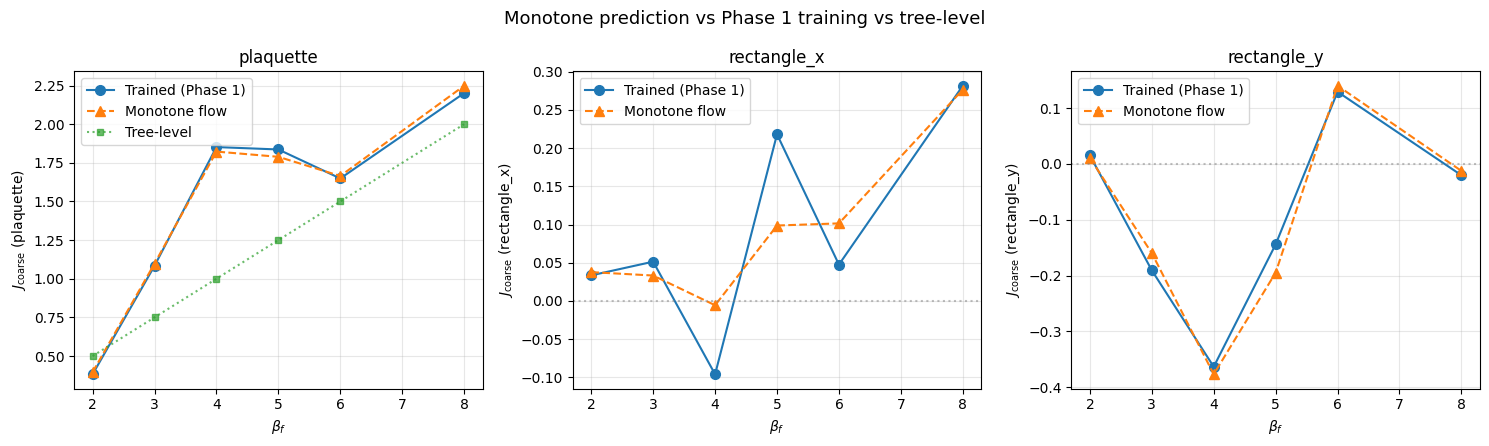


Per-beta plaquette comparison:
  beta     Trained   Predicted        Tree       |err|
----------------------------------------------------
   2.0      0.3819      0.3954      0.5000      0.0135
   3.0      1.0837      1.0979      0.7500      0.0142
   4.0      1.8519      1.8226      1.0000      0.0292
   5.0      1.8362      1.7888      1.2500      0.0475
   6.0      1.6488      1.6647      1.5000      0.0159
   8.0      2.2009      2.2485      2.0000      0.0476


In [7]:
pred = torch.tensor(result.predicted_J_coarse)
actual = torch.tensor(result.actual_J_coarse)
tree = torch.tensor(result.tree_level_J_coarse)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, name in enumerate(result.basis):
    ax = axes[idx]
    ax.plot(betas, actual[:, idx].numpy(), "o-", label="Trained (Phase 1)", markersize=7)
    ax.plot(betas, pred[:, idx].numpy(), "^--", label="Monotone flow", markersize=7)
    if name == "plaquette":
        ax.plot(betas, tree[:, idx].numpy(), "s:", label="Tree-level", markersize=5, alpha=0.7)
    else:
        ax.axhline(0, ls=":", color="gray", alpha=0.5)
    ax.set_xlabel("$\\beta_f$")
    ax.set_ylabel(f"$J_\\mathrm{{coarse}}$ ({name})")
    ax.set_title(name)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Monotone prediction vs Phase 1 training vs tree-level", fontsize=13)
fig.tight_layout()
plt.show()

print("\nPer-beta plaquette comparison:")
print(f"{'beta':>6s}  {'Trained':>10s}  {'Predicted':>10s}  {'Tree':>10s}  {'|err|':>10s}")
print("-" * 52)
for i, b in enumerate(betas):
    err = abs(pred[i, 0].item() - actual[i, 0].item())
    print(f"{b:6.1f}  {actual[i,0]:10.4f}  {pred[i,0]:10.4f}  {tree[i,0]:10.4f}  {err:10.4f}")

## $\beta$ Function (Flow Velocity)

The RG $\beta$ function is $-\nabla_{\mathbf{J}} C(\mathbf{J})$,
the velocity of the coupling flow.
We evaluate it along the pure-Wilson line $\mathbf{J} = (\beta, 0, 0)$.

/home/genie/git/InverseRG/.venv/lib/python3.11/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


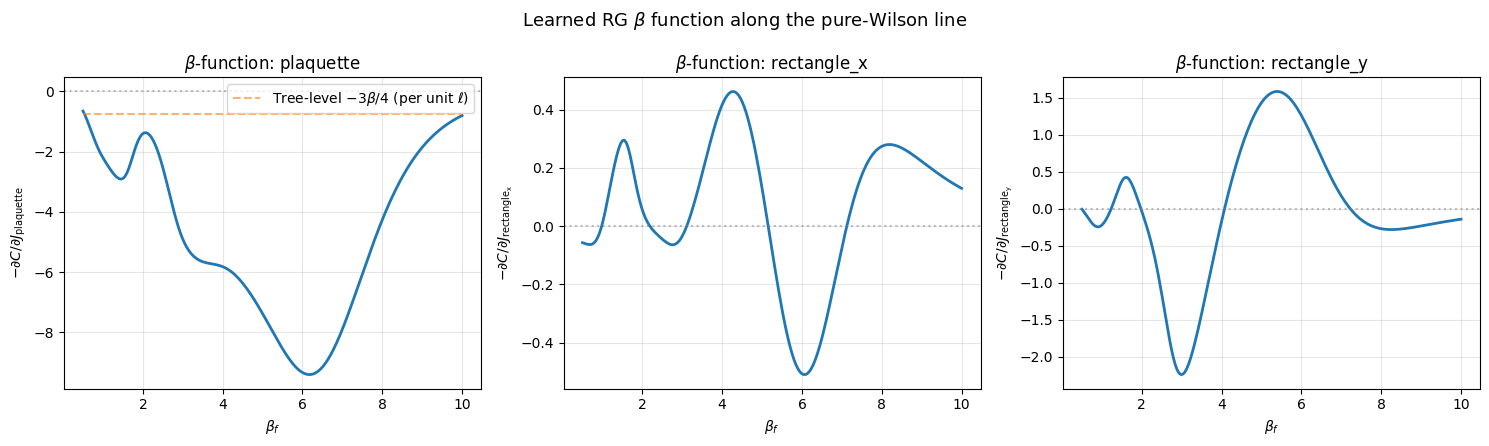

In [8]:
beta_dense = torch.linspace(0.5, 10.0, 200)
J_line = torch.zeros(200, 3)
J_line[:, 0] = beta_dense

with torch.no_grad():
    bf = monotone.beta_function(J_line)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for idx, name in enumerate(result.basis):
    ax = axes[idx]
    ax.plot(beta_dense.numpy(), bf[:, idx].numpy(), linewidth=2)
    ax.axhline(0, ls=":", color="gray", alpha=0.5)
    if name == "plaquette":
        tree_bf = -0.75 * torch.ones_like(beta_dense)
        ax.plot(beta_dense.numpy(), tree_bf.numpy(), "--", alpha=0.6,
                label="Tree-level $-3\\beta/4$ (per unit $\\ell$)")
        ax.legend()
    ax.set_xlabel("$\\beta_f$")
    ax.set_ylabel(f"$-\\partial C / \\partial J_\\mathrm{{{name}}}$")
    ax.set_title(f"$\\beta$-function: {name}")
    ax.grid(True, alpha=0.3)

fig.suptitle("Learned RG $\\beta$ function along the pure-Wilson line", fontsize=13)
fig.tight_layout()
plt.show()

## RG Monotone Landscape

Visualise $C(\mathbf{J})$ on the $(\beta_\text{plaq},\; 0,\; 0)$ slice
and in the 2D $(\beta_\text{plaq},\; \beta_\text{rect\_x})$ plane.

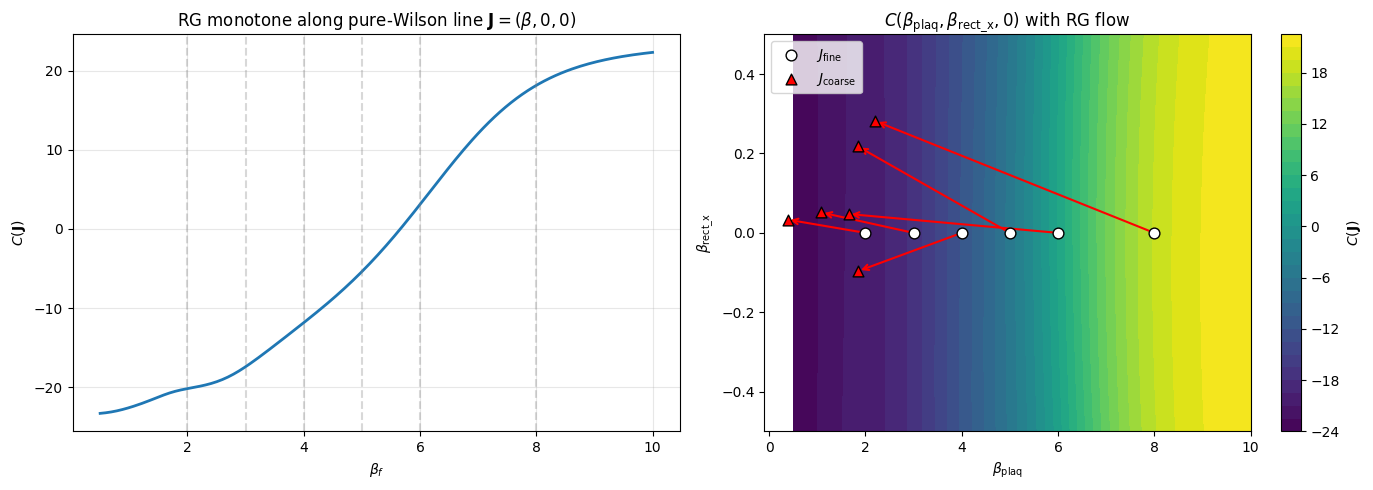

In [9]:
# 1D slice along pure-Wilson line
with torch.no_grad():
    C_line = monotone(J_line)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(beta_dense.numpy(), C_line.numpy(), linewidth=2)
for b in betas:
    ax.axvline(b, ls="--", color="gray", alpha=0.3)
ax.set_xlabel("$\\beta_f$")
ax.set_ylabel("$C(\\mathbf{J})$")
ax.set_title("RG monotone along pure-Wilson line $\\mathbf{J} = (\\beta, 0, 0)$")
ax.grid(True, alpha=0.3)

# 2D landscape: plaquette vs rectangle_x
plaq_range = torch.linspace(0.5, 10.0, 80)
rect_range = torch.linspace(-0.5, 0.5, 80)
PP, RR = torch.meshgrid(plaq_range, rect_range, indexing="ij")
J_grid = torch.zeros(80, 80, 3)
J_grid[:, :, 0] = PP
J_grid[:, :, 1] = RR

with torch.no_grad():
    C_grid = monotone(J_grid)

ax = axes[1]
cf = ax.contourf(PP.numpy(), RR.numpy(), C_grid.numpy(), levels=30, cmap="viridis")
fig.colorbar(cf, ax=ax, label="$C(\\mathbf{J})$")

# overlay collected points
ax.scatter(collected.J_fine[:, 0].numpy(),
           collected.J_fine[:, 1].numpy(),
           marker="o", c="white", edgecolors="black", s=60, zorder=5, label="$J_\\mathrm{fine}$")
ax.scatter(collected.J_coarse[:, 0].numpy(),
           collected.J_coarse[:, 1].numpy(),
           marker="^", c="red", edgecolors="black", s=60, zorder=5, label="$J_\\mathrm{coarse}$")

# flow arrows
for i in range(len(betas)):
    dx = collected.J_coarse[i, 0].item() - collected.J_fine[i, 0].item()
    dy = collected.J_coarse[i, 1].item() - collected.J_fine[i, 1].item()
    ax.annotate("", xy=(collected.J_coarse[i, 0].item(), collected.J_coarse[i, 1].item()),
                xytext=(collected.J_fine[i, 0].item(), collected.J_fine[i, 1].item()),
                arrowprops=dict(arrowstyle="->", color="red", lw=1.5))

ax.set_xlabel("$\\beta_\\mathrm{plaq}$")
ax.set_ylabel("$\\beta_\\mathrm{rect\\_x}$")
ax.set_title("$C(\\beta_\\mathrm{plaq}, \\beta_\\mathrm{rect\\_x}, 0)$ with RG flow")
ax.legend(loc="upper left")

fig.tight_layout()
plt.show()

## Multi-Step RG Flow

Starting from $\mathbf{J}_\text{fine} = (\beta, 0, 0)$, iterate the flow multiple
times to see where couplings evolve under repeated blocking.

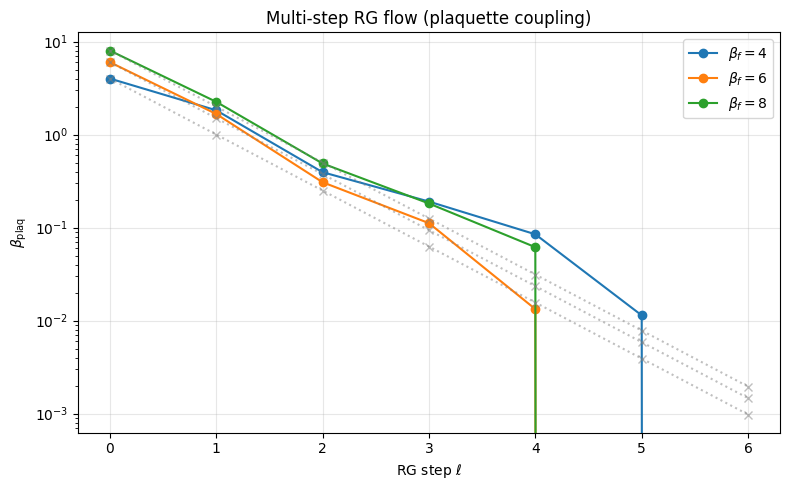

In [10]:
n_rg_steps = 6
start_betas = [4.0, 6.0, 8.0]

fig, ax = plt.subplots(figsize=(8, 5))

for sb in start_betas:
    J = torch.tensor([sb, 0.0, 0.0])
    trajectory = [J.clone()]
    for _ in range(n_rg_steps):
        J = rg_flow_step(monotone, J, n_steps=20, create_graph=False).detach()
        trajectory.append(J.clone())
    traj = torch.stack(trajectory)
    ax.plot(range(n_rg_steps + 1), traj[:, 0].numpy(), "o-",
            label=f"$\\beta_f = {sb:.0f}$", markersize=6)

# Tree-level reference
for sb in start_betas:
    tree_traj = [sb]
    b = sb
    for _ in range(n_rg_steps):
        b = b / 4.0
        tree_traj.append(b)
    ax.plot(range(n_rg_steps + 1), tree_traj, "x:", alpha=0.5, color="gray")

ax.set_xlabel("RG step $\\ell$")
ax.set_ylabel("$\\beta_\\mathrm{plaq}$")
ax.set_title("Multi-step RG flow (plaquette coupling)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale("log")
fig.tight_layout()
plt.show()

## Summary

**Stage 1** collected $(\mathbf{J}_\text{fine}, \mathbf{J}_\text{coarse}^*)$ pairs
by running Phase 1 training at each $\beta$ value. The learned plaquette coupling
tracks $\beta_f/4$ with small corrections; rectangle couplings are generated
at nonzero but small values.

**Stage 2** trained an RG monotone network $C_\theta(\mathbf{J})$ whose gradient
flow reproduces the Phase 1 coupling mapping. After training:
- The predicted $\mathbf{J}_\text{coarse}$ closely matches the independently
  trained values across the $\beta$ grid.
- The learned $\beta$ function (flow velocity) can be evaluated at any point in
  coupling space, not just the training grid.
- Multi-step RG trajectories show couplings flowing toward strong coupling
  ($\beta \to 0$), consistent with the absence of a phase transition in
  2D compact U(1).

**Next steps:**
- Increase lattice size and number of configurations for production-quality data.
- Extend to end-to-end monotone training (jointly with the blocker).
- Explore the monotone landscape for hints about the structure of the
  effective theory space.